In [ ]:
!pip install matplotlib seaborn pandas --quiet

In [ ]:

import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings

warnings.filterwarnings("ignore")

sns.set_theme(style = "whitegrid", palette="muted")
plt.rcParams["figure.dpi"] = 120
plt.rcParams["figure.figsize"] = (10, 5)
plt.rcParams["axes.titlesize"] = 14
plt.rcParams["axes.titleweight"] = "bold"

print("Libraries ready!!")

Libraries ready!!


In [ ]:
from google.colab import files

print("Upload your netflix.cleaned.csv file:")
uploaded = files.upload()

df = pd.read_csv("netflix_cleaned.csv")
genre_df = pd.read_csv("netflix_genres.csv")

print(f"Main table loaded: {len(df)} rows")
print(f"Genre table loaded: {len(genre_df)} rows")
print("\nColumns Available:")
print(df.columns.tolist())

Upload your netflix.cleaned.csv file:


Saving netflix_cleaned.csv to netflix_cleaned.csv
Saving netflix_genres.csv to netflix_genres.csv
Main table loaded: 8807 rows
Genre table loaded: 19323 rows

Columns Available:
['show_id', 'type', 'title', 'director', 'cast', 'country', 'date_added', 'release_year', 'rating', 'duration', 'listed_in', 'description', 'year_added', 'month_added', 'duration_value', 'duration_unit', 'tmdb_id', 'tmdb_popularity', 'tmdb_vote_avg', 'tmdb_vote_count', 'release_date', 'days_to_netflix', 'is_likely_original', 'cast_size', 'genre_count', 'primary_genre', 'primary_country', 'decade']


In [ ]:
print("=" * 50)
print("DATASET SUMMARY")
print("=" * 50)
print(f"Total titles: {len(df)}")
print(f"Movies: {len(df[df['type'] == 'Movie'])}")
print(f"TV Shows: {len(df[df['type'] == 'TV Show'])}")
print(f"Countries covered: {df['primary_country'].nunique()}")
print(f"Unique genres: {genre_df['genre'].nunique()}")
print(f"Year range: {int(df['release_year'].min())} - {int(df['release_year'].max())}")
print(f"Avg TMDB rating: {df['tmdb_vote_avg'].mean():.2f}/10")
print("=" * 50)

DATASET SUMMARY
Total titles: 8807
Movies: 6131
TV Shows: 2676
Countries covered: 86
Unique genres: 42
Year range: 1925 - 2021
Avg TMDB rating: 6.58/10


Movies vs TV Shows - Pie Chart


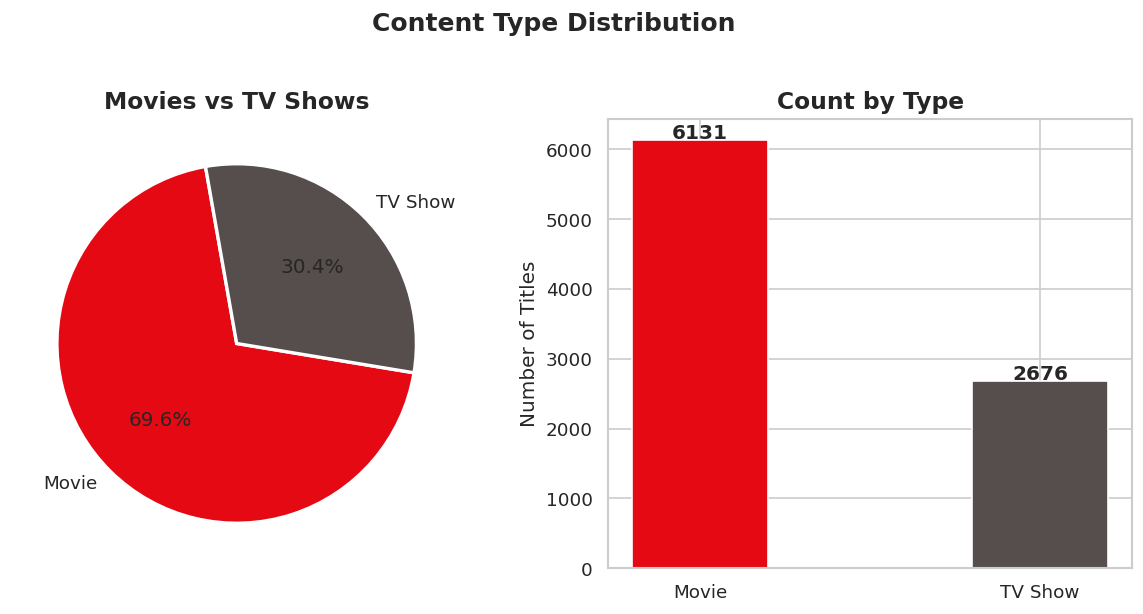

Insight: Netflix has significantly more Movies than TV Shows.


In [ ]:
print("=" * 50)
print("Movies vs TV Shows - Pie Chart")
print("=" * 50)
from matplotlib import axes
counts = df["type"].value_counts()

fig, axes = plt.subplots(1, 2, figsize=(10,5))

axes[0].pie(
    counts,
    labels = counts.index,
    autopct = "%1.1f%%",
    startangle = 100,
    colors = ["#E50914", "#564d4d"],
    wedgeprops = {"edgecolor": "white", "linewidth":2}
)
axes[0].set_title("Movies vs TV Shows")

axes[1].bar(counts.index, counts.values, color = ['#E50914', '#564d4d'], width=0.4)
axes[1].set_title("Count by Type")
axes[1].set_ylabel("Number of Titles")
for i, v in enumerate(counts.values):
  axes[1].text(i, v + 30, str(v), ha="center", fontweight="bold")

plt.suptitle("Content Type Distribution", fontsize=15, fontweight="bold", y=1.02)
plt.tight_layout()
plt.savefig("chart1_type_distribution.png", bbox_inches="tight")
plt.show()
print("Insight: Netflix has significantly more Movies than TV Shows.")

Content Added Per Year


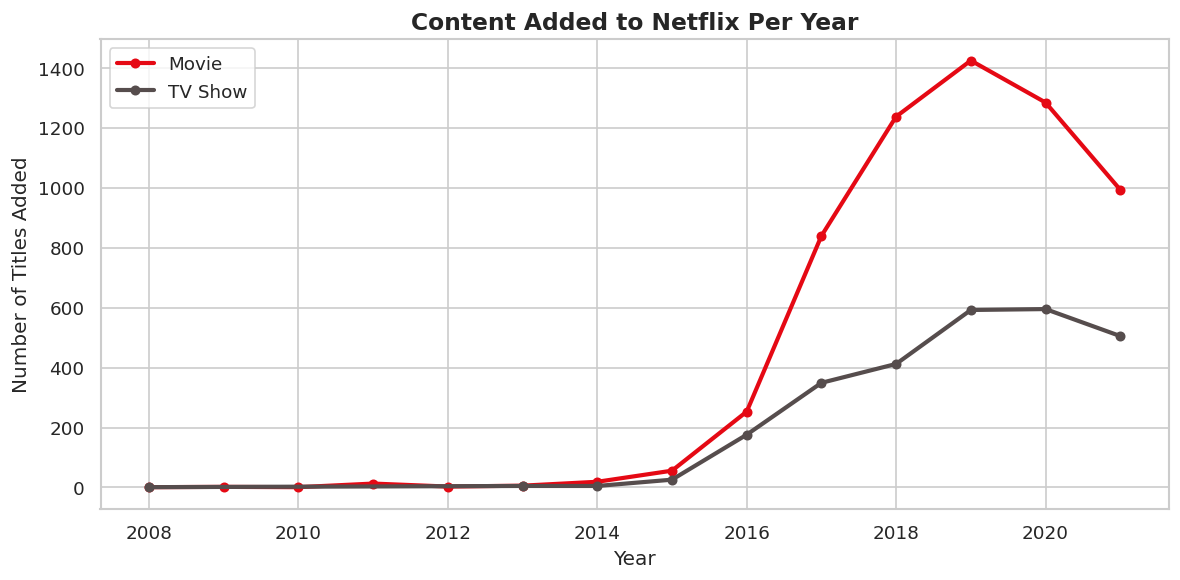

Insight: Netflix massively scaled content additions from 2015 onwards!


In [ ]:
print("=" * 50)
print("Content Added Per Year")
print("=" * 50)

yearly = df.groupby(["year_added", "type"]).size().reset_index(name="count")

fig, ax = plt.subplots(figsize=(10,5))

for content_type, color in [("Movie", "#E50914"), ("TV Show","#564d4d")]:
  data = yearly[yearly["type"] == content_type]
  ax.plot(
      data["year_added"], data["count"],
      marker='o', label=content_type,
      color=color, linewidth=2.5, markersize=5
  )

ax.set_title("Content Added to Netflix Per Year")
ax.set_xlabel("Year")
ax.set_ylabel("Number of Titles Added")
ax.legend()
ax.xaxis.set_major_locator(mticker.MaxNLocator(integer=True))

plt.tight_layout()
plt.savefig("chart2_content_per_year.png", bbox_inches="tight")
plt.show()
print("Insight: Netflix massively scaled content additions from 2015 onwards!")

Top 10 Genres


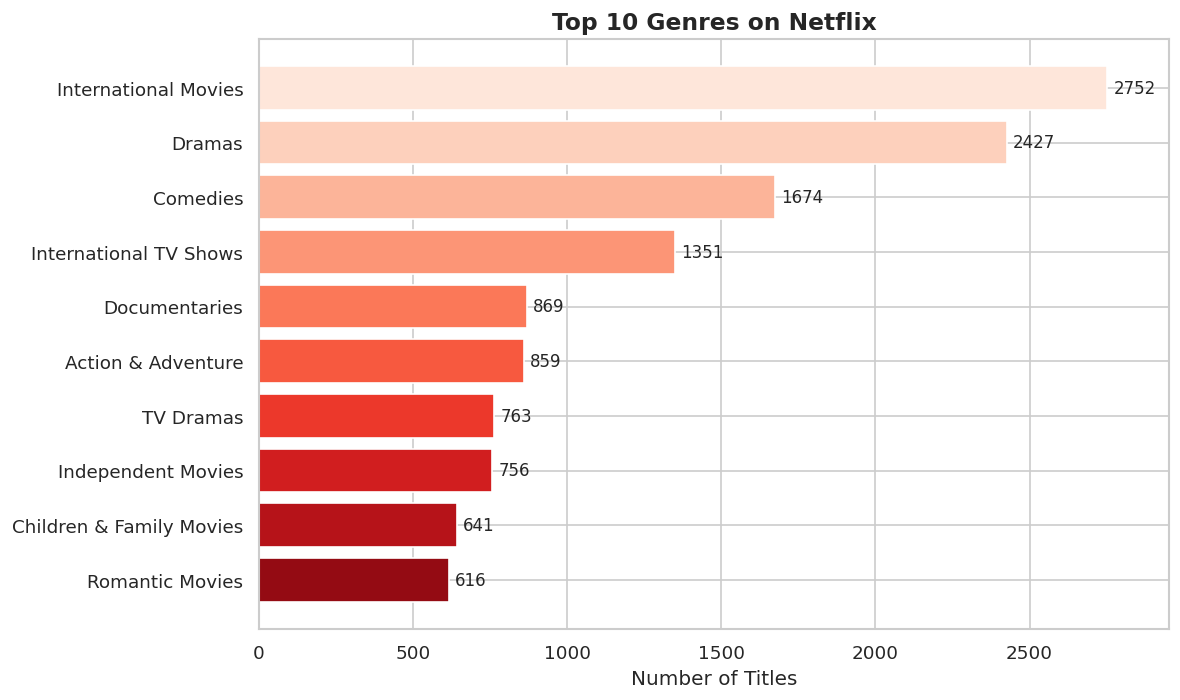

Insight: International Movies and Drama's Dominate Netflix's library


In [ ]:
print("=" * 50)
print("Top 10 Genres")
print("=" * 50)


top_genres = genre_df["genre"].value_counts().head(10)

fig, ax = plt.subplots(figsize=(10,6))

bars = ax.barh(
    top_genres.index[::-1],
    top_genres.values[::-1],
    color=sns.color_palette("Reds_r", 10)
)

for bar, val in zip(bars, top_genres.values[::-1]):
  ax.text(bar.get_width() + 20, bar.get_y() + bar.get_height() / 2,
          str(val), va="center", fontsize=10)

ax.set_title("Top 10 Genres on Netflix")
ax.set_xlabel("Number of Titles")
ax.set_xlim(0, top_genres.max() + 200)

plt.tight_layout()
plt.savefig("chart3_top_genres.png", bbox_inches="tight")
plt.show()
print("Insight: International Movies and Drama's Dominate Netflix's library")

Top 10 Genres


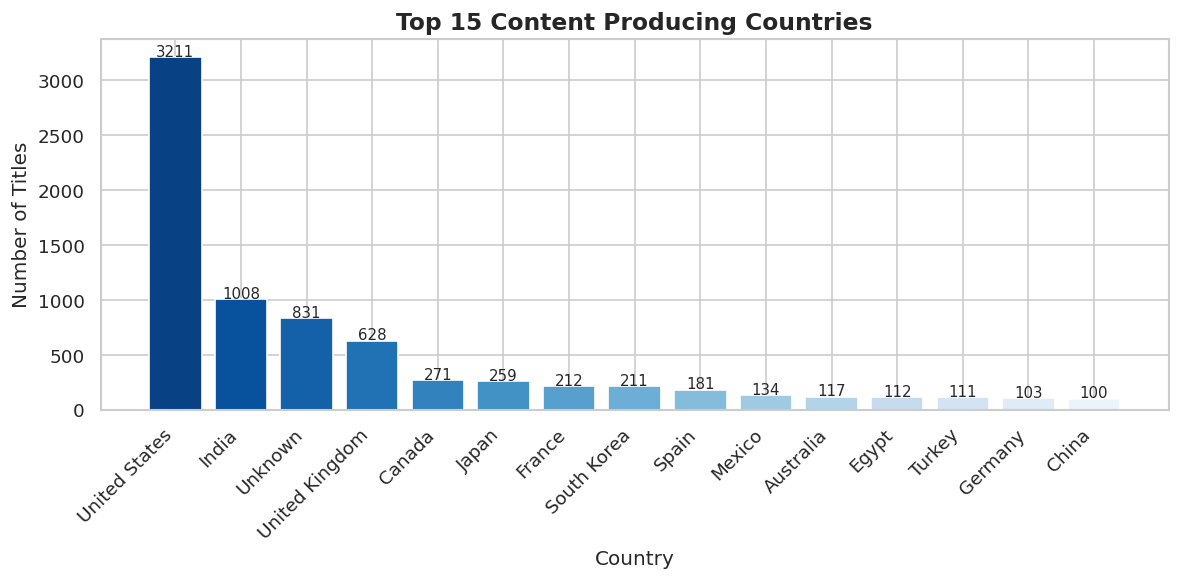

Insight: The US leads by far, followed by India and the UK


In [ ]:
print("=" * 50)
print("Top 10 Genres")
print("=" * 50)

top_countries = df["primary_country"].value_counts().head(15)

fig, ax = plt.subplots(figsize = (10, 5))

bars = ax.bar(
    top_countries.index,
    top_countries.values,
    color=sns.color_palette("Blues_r",15)
)

ax.set_title("Top 15 Content Producing Countries")
ax.set_xlabel("Country")
ax.set_ylabel("Number of Titles")
plt.xticks(rotation=45, ha="right")

for bar in bars:
  ax.text(
      bar.get_x() + bar.get_width()/2,
      bar.get_height() + 10,
      str(int(bar.get_height())),
      ha="center", fontsize=9
  )

plt.tight_layout()
plt.savefig("chart4_top_countries.png", bbox_inches="tight")
plt.show()
print("Insight: The US leads by far, followed by India and the UK")

Top 10 Genres


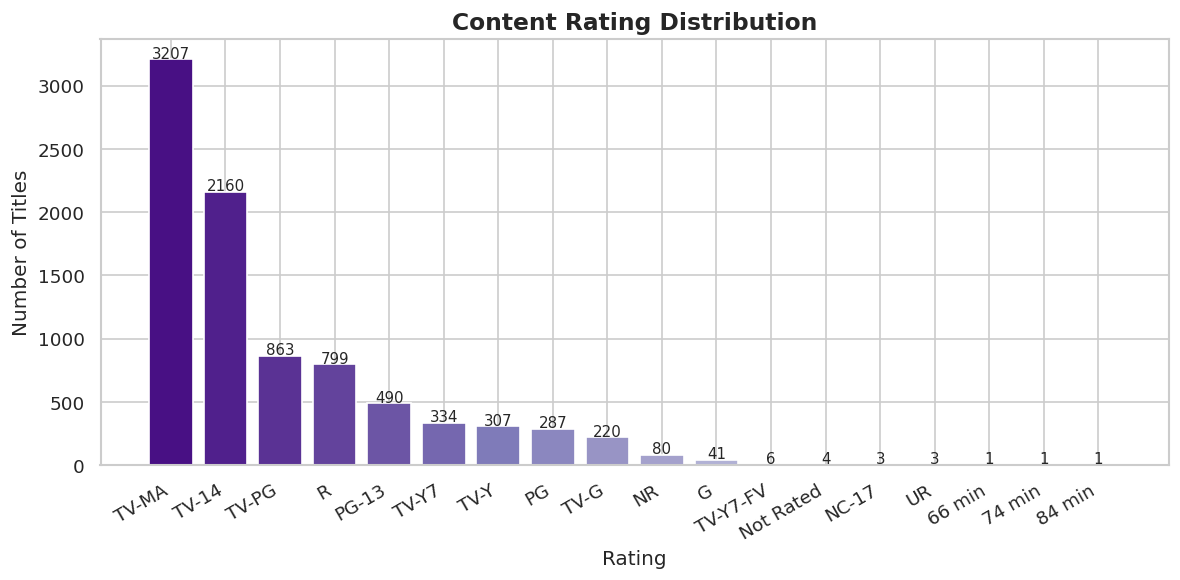

Insight: TV-MA (mature) is the most common rating -Netflix skews adult.


In [ ]:
print("=" * 50)
print("Top 10 Genres")
print("=" * 50)

rating_counts = df["rating"].value_counts()

fig, ax = plt.subplots(figsize=(10,5))

bars = ax.bar(
    rating_counts.index,
    rating_counts.values,
    color = sns.color_palette("Purples_r", len(rating_counts))
)

ax.set_title("Content Rating Distribution")
ax.set_xlabel("Rating")
ax.set_ylabel("Number of Titles")
plt.xticks(rotation=30, ha="right")

for bar in bars:
  ax.text(
      bar.get_x() + bar.get_width() / 2,
      bar.get_height() + 10,
      str(int(bar.get_height())),
      ha="center", fontsize=9
  )

plt.tight_layout()
plt.savefig("chart5_rating_distribution.png", bbox_inches="tight")
plt.show()
print("Insight: TV-MA (mature) is the most common rating -Netflix skews adult.")

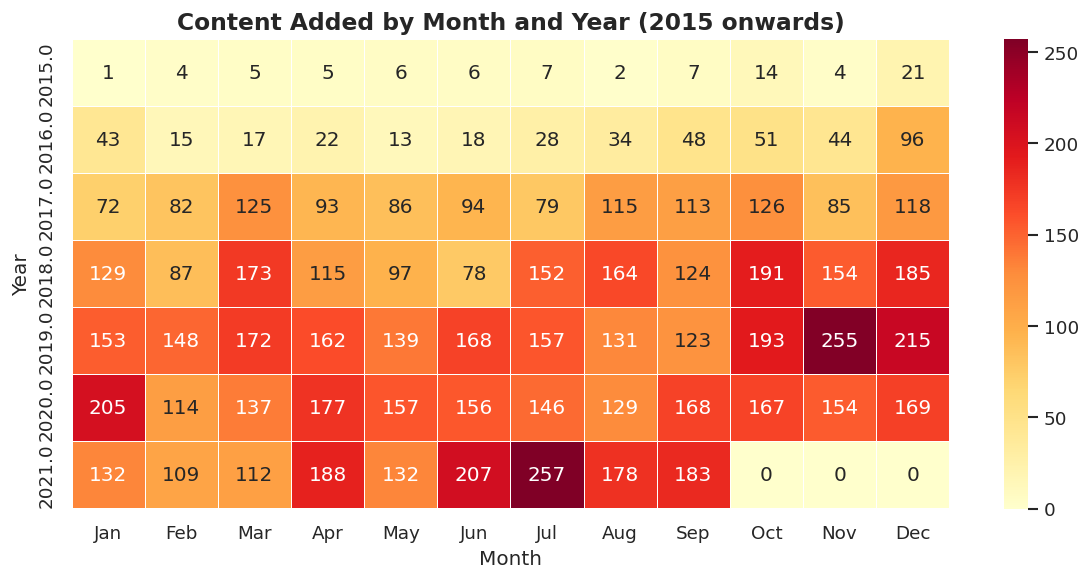

Insight: Q4 Oct-Dec sees the highest content drops - holiday strategy


In [ ]:
heatmap_data = df.groupby(["year_added","month_added"]).size().unstack(fill_value=0)

heatmap_data = heatmap_data[heatmap_data.index >= 2015]

month_names = ["Jan", "Feb", "Mar", "Apr", "May", "Jun", "Jul", "Aug", "Sep", "Oct", "Nov", "Dec"]
heatmap_data.columns = [month_names[int(m)-1] for m in heatmap_data.columns]

fig, ax = plt.subplots(figsize=(10,5))

sns.heatmap(
    heatmap_data,
    cmap="YlOrRd",
    linewidths=0.5,
    annot= True,
    fmt="d",
    ax = ax
)

ax.set_title("Content Added by Month and Year (2015 onwards)")
ax.set_xlabel("Month")
ax.set_ylabel("Year")

plt.tight_layout()
plt.savefig("chart6_monthly_heatmap.png", bbox_inches="tight")
plt.show()
print("Insight: Q4 Oct-Dec sees the highest content drops - holiday strategy")

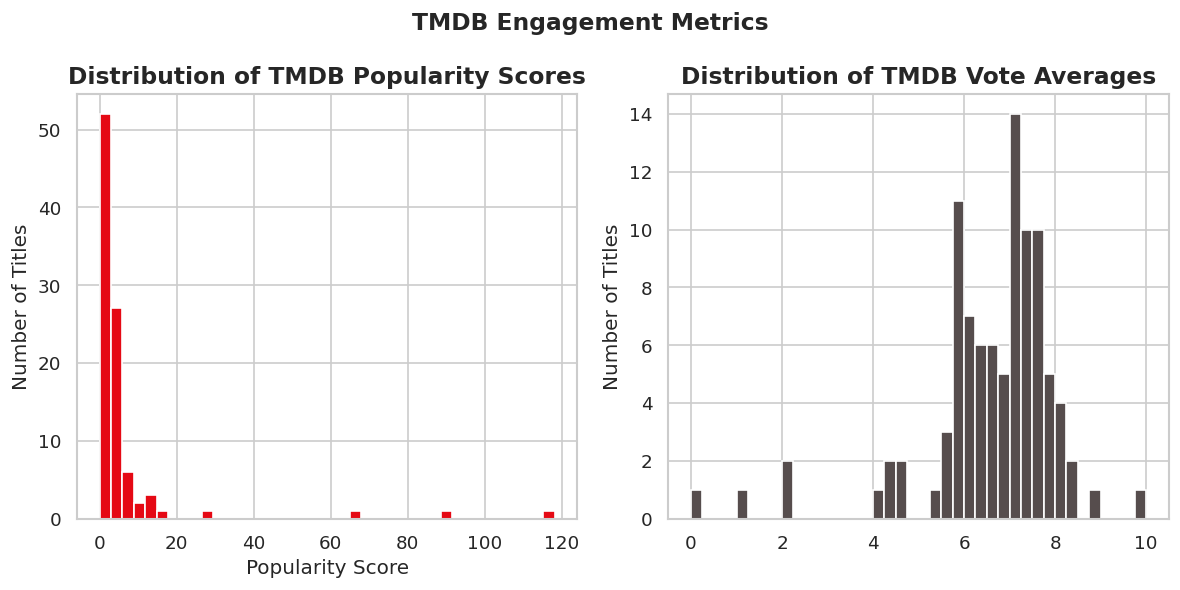

Insight: Most titles cluster around 6-7 rating. Very few go above 8.


In [ ]:
tmdb_df = df[df["tmdb_popularity"].notna()].copy()

fig, axes = plt.subplots(1, 2, figsize=(10,5))

axes[0].hist(
    tmdb_df["tmdb_popularity"],
    bins=40,
    color="#E50914",
    edgecolor="white"
)
axes[0].set_title("Distribution of TMDB Popularity Scores")
axes[0].set_xlabel("Popularity Score")
axes[0].set_ylabel("Number of Titles")

axes[1].hist(
    tmdb_df["tmdb_vote_avg"],
    bins=40,
    color="#564d4d",
    edgecolor="white"
)
axes[1].set_title("Distribution of TMDB Vote Averages")
axes[1].set_ylabel("Vote Average (Out of 10)")
axes[1].set_ylabel("Number of Titles")

plt.suptitle("TMDB Engagement Metrics", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig("chart7_tmdb_distribution.png",bbox_inches="tight")
plt.show()
print("Insight: Most titles cluster around 6-7 rating. Very few go above 8.")

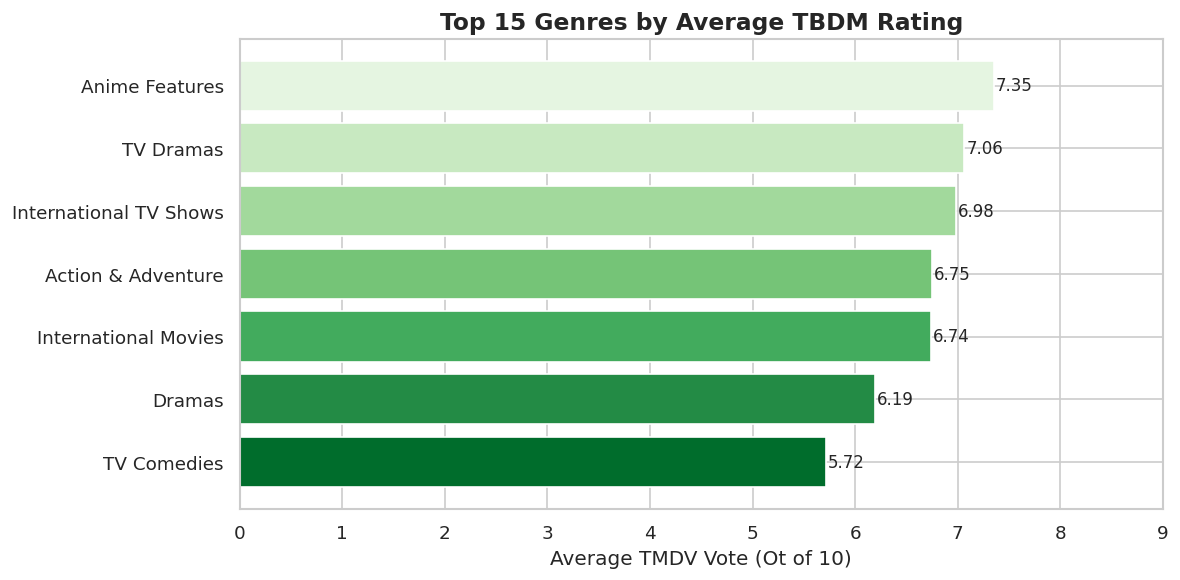

Insight: Documentaries and Classic Movies tend to rate highest on TMDB


In [ ]:
genre_ratings = genre_df.merge(
    df[["show_id", "tmdb_vote_avg"]],
    on = "show_id",
    how = "left"
)

avg_by_genre = (
    genre_ratings[genre_ratings["tmdb_vote_avg"].notna()]
    .groupby("genre")["tmdb_vote_avg"]
    .agg(["mean", "count"])
    .reset_index()
)

avg_by_genre = avg_by_genre[avg_by_genre["count"] >= 10]
avg_by_genre = avg_by_genre.sort_values("mean", ascending=False).head(15)

fig, ax = plt.subplots(figsize=(10,5))

bars = ax.barh(
    avg_by_genre["genre"][::-1],
    avg_by_genre["mean"][::-1],
    color=sns.color_palette("Greens_r", len(avg_by_genre))
)

for bar, val in zip(bars, avg_by_genre["mean"][::-1]):
  ax.text(bar.get_width() + 0.02, bar.get_y() + bar.get_height() / 2,
          f"{val:.2f}", va="center", fontsize=10)

ax.set_title("Top 15 Genres by Average TBDM Rating")
ax.set_xlabel("Average TMDV Vote (Ot of 10)")
ax.set_xlim(0,9)

plt.tight_layout()
plt.savefig("chart8_genre_vs_rating.png", bbox_inches="tight")
plt.show()
print("Insight: Documentaries and Classic Movies tend to rate highest on TMDB")

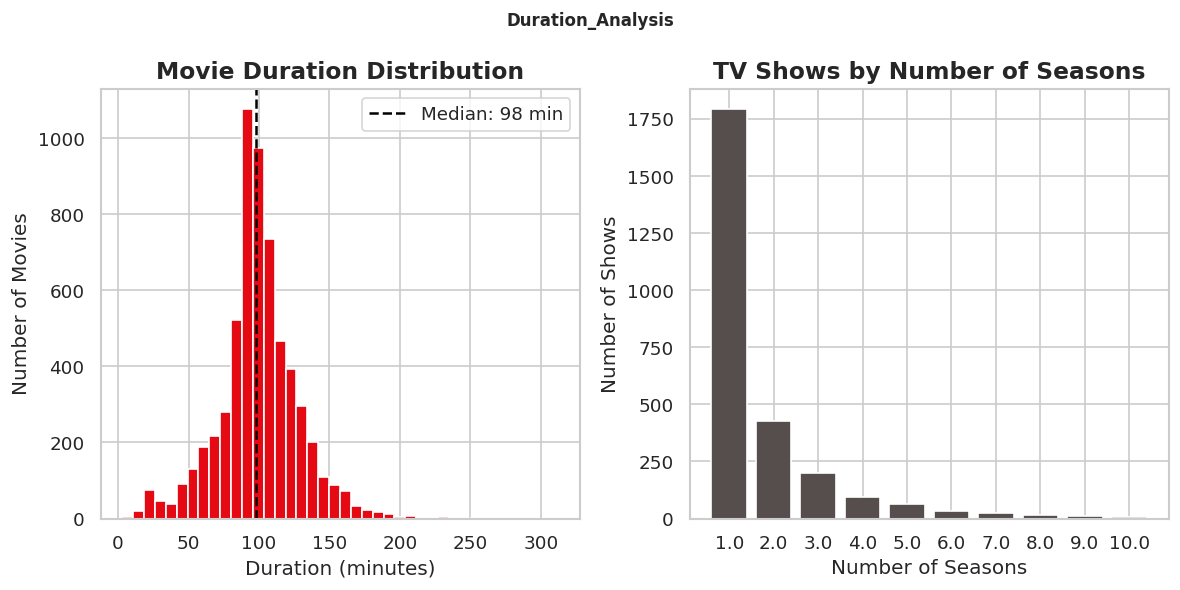

Insight: Most Movies are 90 to 100 mins. Most TV shows have only 1 season


In [ ]:
from matplotlib.lines import lineStyles
fig, axes = plt.subplots(1, 2, figsize=(10, 5))

movies = df[(df["type"] == "Movie") & (df["duration_value"].notna())]
axes[0].hist(
    movies["duration_value"],
    bins=40,
    color="#E50914",
    edgecolor = "white"
)

axes[0].set_title("Movie Duration Distribution")
axes[0].set_xlabel("Duration (minutes)")
axes[0].set_ylabel("Number of Movies")
axes[0].axvline(
    movies["duration_value"].median(), color="black", linestyle="--", linewidth=1.5, label=f'Median: {int(movies["duration_value"].median())} min'
)
axes[0].legend()

shows = df[(df["type"] == "TV Show") & (df["duration_value"].notna())]
season_counts = shows["duration_value"].value_counts().sort_index().head(10)
axes[1].bar(
    season_counts.index.astype(str),
    season_counts.values,
    color="#564d4d"
)
axes[1].set_title("TV Shows by Number of Seasons")
axes[1].set_xlabel("Number of Seasons")
axes[1].set_ylabel("Number of Shows")

plt.suptitle("Duration_Analysis", fontsize=10, fontweight="bold")
plt.tight_layout()
plt.savefig("chart9_duration_analysis.png", bbox_inches="tight")
plt.show()
print("Insight: Most Movies are 90 to 100 mins. Most TV shows have only 1 season")

In [ ]:
print("=" * 50)
print("EDA Complete - Key Insights Summary")
print("=" * 50)
print("1. Netflix has more Movies than TV Shows (~70/30 split)")
print("2. Content additions exploded after 2015")
print("3. International Movies & Dramas are top genres")
print("4. USA, India, UK are top producing countries")
print("5. TV-MA is the most common rating (adult content)")
print("6. Q4 (Oct–Dec) sees the most content drops")
print("7. Most titles have a TMDB rating between 6–7")
print("8. Documentaries tend to have the highest ratings")
print("9. Median movie length is ~90 min; most shows have 1 season")
print("=" * 50)
print("\n All 9 charts saved as PNG files in Colab")
print("\n You can download them from the Files Panel on the left")

EDA Complete - Key Insights Summary
1. Netflix has more Movies than TV Shows (~70/30 split)
2. Content additions exploded after 2015
3. International Movies & Dramas are top genres
4. USA, India, UK are top producing countries
5. TV-MA is the most common rating (adult content)
6. Q4 (Oct–Dec) sees the most content drops
7. Most titles have a TMDB rating between 6–7
8. Documentaries tend to have the highest ratings
9. Median movie length is ~90 min; most shows have 1 season

 All 9 charts saved as PNG files in Colab

 You can download them from the Files Panel on the left
